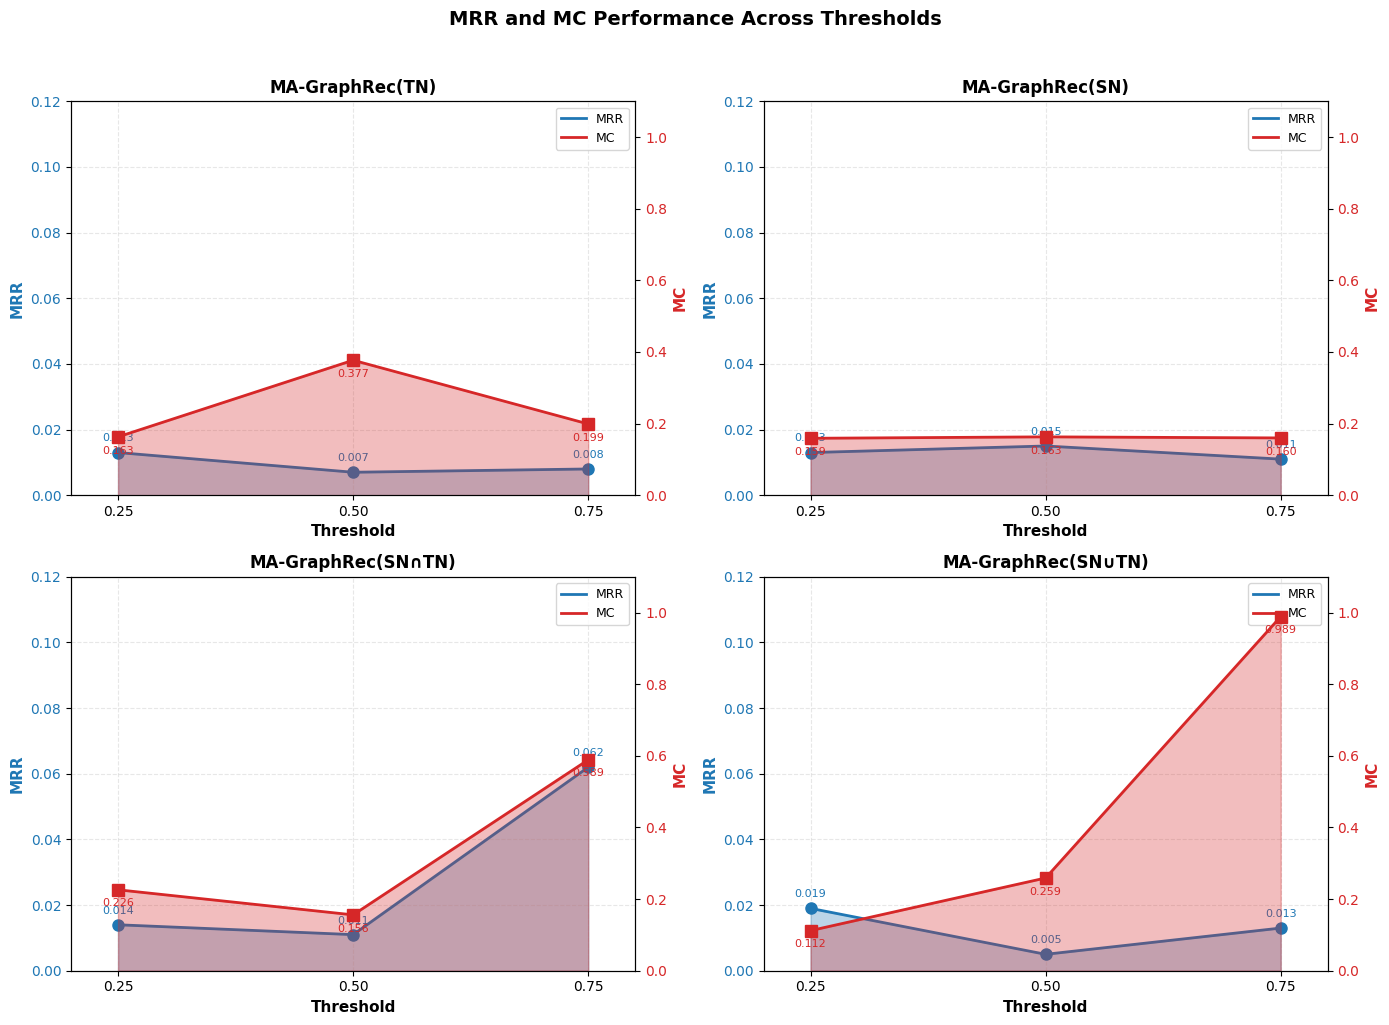

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data for all algorithms
algorithms = ['MA-GraphRec(TN)', 'MA-GraphRec(SN)', 'MA-GraphRec(SN∩TN)', 'MA-GraphRec(SN∪TN)']
thresholds = [0.25, 0.50, 0.75]

mrr_data = {
    'MA-GraphRec(TN)': [0.013, 0.007, 0.008],
    'MA-GraphRec(SN)': [0.013, 0.015, 0.011],
    'MA-GraphRec(SN∩TN)': [0.014, 0.011, 0.062],
    'MA-GraphRec(SN∪TN)': [0.019, 0.005, 0.013]
}

mc_data = {
    'MA-GraphRec(TN)': [0.163, 0.377, 0.199],
    'MA-GraphRec(SN)': [0.159, 0.163, 0.160],
    'MA-GraphRec(SN∩TN)': [0.226, 0.156, 0.589],
    'MA-GraphRec(SN∪TN)': [0.112, 0.259, 0.989]
}

# Colors for algorithms
mrr_colors = ['#1f77b4', '#2ca02c', '#9467bd', '#17becf']  # Blues/Greens for MRR
mc_colors = ['#d62728', '#ff7f0e', '#e377c2', '#bcbd22']   # Reds/Oranges for MC

# Create subplots - one for each algorithm
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_smooth = np.linspace(0.25, 0.75, 100)

for idx, algo in enumerate(algorithms):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    # Get data for this algorithm
    mrr_values = mrr_data[algo]
    mc_values = mc_data[algo]
    
    # Interpolate for smooth curves
    mrr_smooth = np.interp(x_smooth, thresholds, mrr_values)
    mc_smooth = np.interp(x_smooth, thresholds, mc_values)
    
    # Plot MRR with area
    ax1.fill_between(x_smooth, mrr_smooth, alpha=0.3, color='#1f77b4')
    ax1.plot(x_smooth, mrr_smooth, color='#1f77b4', linewidth=2, label='MRR')
    ax1.plot(thresholds, mrr_values, 'o', color='#1f77b4', markersize=8)
    # Add value annotations for MRR
    for x, y in zip(thresholds, mrr_values):
        ax1.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                    xytext=(0, 8), ha='center', fontsize=8, color='#1f77b4')
    
    ax1.set_xlabel('Threshold', fontsize=11, fontweight='bold')
    ax1.set_ylabel('MRR', color='#1f77b4', fontsize=11, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.set_ylim(0, 0.12)
    ax1.set_xlim(0.2, 0.8)
    ax1.set_xticks(thresholds)
    
    # Plot MC with area
    ax2.fill_between(x_smooth, mc_smooth, alpha=0.3, color='#d62728')
    ax2.plot(x_smooth, mc_smooth, color='#d62728', linewidth=2, label='MC')
    ax2.plot(thresholds, mc_values, 's', color='#d62728', markersize=8)
    # Add value annotations for MC
    for x, y in zip(thresholds, mc_values):
        ax2.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                    xytext=(0, -12), ha='center', fontsize=8, color='#d62728')
    
    ax2.set_ylabel('MC', color='#d62728', fontsize=11, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    ax2.set_ylim(0, 1.1)
    
    # Title and legend
    algo_short = algo.split('(')[1].replace(')', '')
    ax1.set_title(f'MA-GraphRec({algo_short})', fontsize=12, fontweight='bold')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    
    ax1.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('MRR and MC Performance Across Thresholds', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mrr_mc_dual_axis.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.savefig('mrr_mc_dual_axis.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

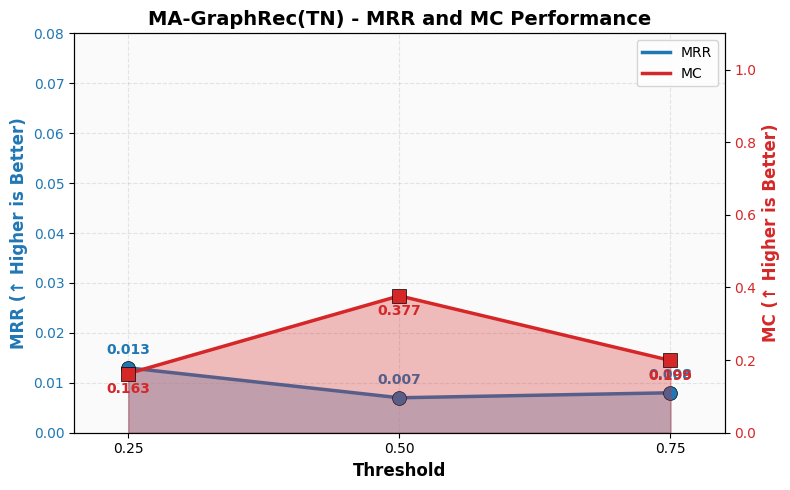

Saved: mrr_mc_TN.pdf and mrr_mc_TN.png


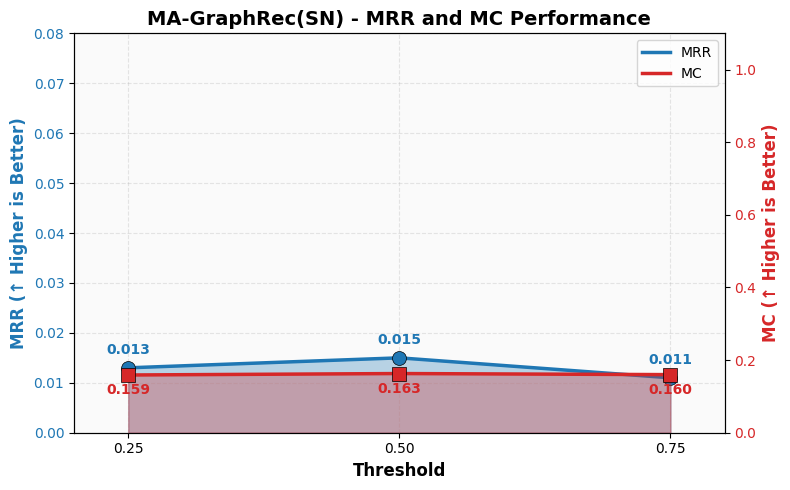

Saved: mrr_mc_SN.pdf and mrr_mc_SN.png


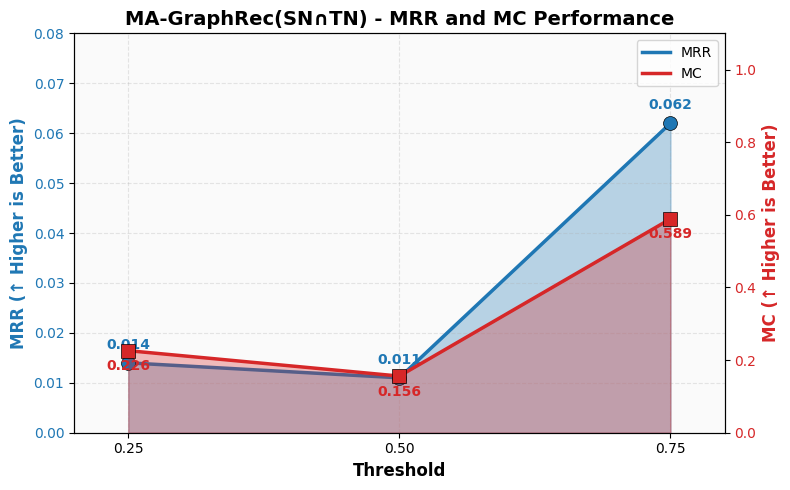

Saved: mrr_mc_SN_intersection_TN.pdf and mrr_mc_SN_intersection_TN.png


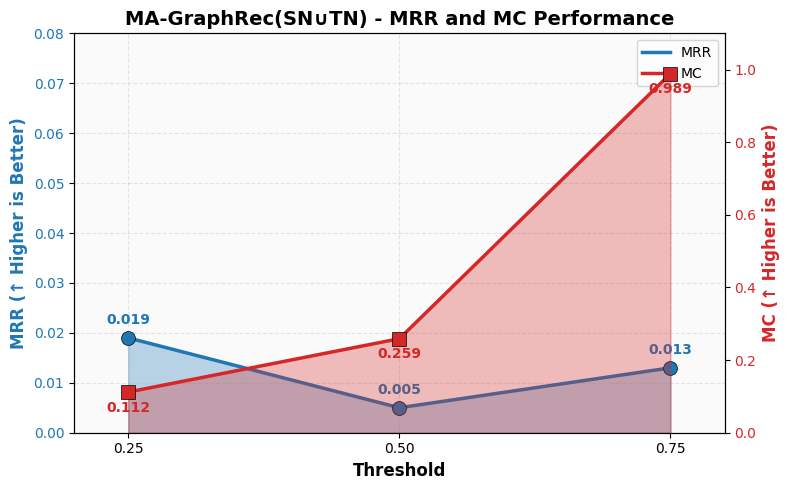

Saved: mrr_mc_SN_union_TN.pdf and mrr_mc_SN_union_TN.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data for all algorithms
algorithms = ['MA-GraphRec(TN)', 'MA-GraphRec(SN)', 'MA-GraphRec(SN∩TN)', 'MA-GraphRec(SN∪TN)']
thresholds = [0.25, 0.50, 0.75]

mrr_data = {
    'MA-GraphRec(TN)': [0.013, 0.007, 0.008],
    'MA-GraphRec(SN)': [0.013, 0.015, 0.011],
    'MA-GraphRec(SN∩TN)': [0.014, 0.011, 0.062],
    'MA-GraphRec(SN∪TN)': [0.019, 0.005, 0.013]
}

mc_data = {
    'MA-GraphRec(TN)': [0.163, 0.377, 0.199],
    'MA-GraphRec(SN)': [0.159, 0.163, 0.160],
    'MA-GraphRec(SN∩TN)': [0.226, 0.156, 0.589],
    'MA-GraphRec(SN∪TN)': [0.112, 0.259, 0.989]
}

x_smooth = np.linspace(0.25, 0.75, 100)

# Generate individual plot for each algorithm
for algo in algorithms:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()
    
    # Get data for this algorithm
    mrr_values = mrr_data[algo]
    mc_values = mc_data[algo]
    
    # Interpolate for smooth curves
    mrr_smooth = np.interp(x_smooth, thresholds, mrr_values)
    mc_smooth = np.interp(x_smooth, thresholds, mc_values)
    
    # Plot MRR with area
    ax1.fill_between(x_smooth, mrr_smooth, alpha=0.3, color='#1f77b4')
    ax1.plot(x_smooth, mrr_smooth, color='#1f77b4', linewidth=2.5, label='MRR')
    ax1.plot(thresholds, mrr_values, 'o', color='#1f77b4', markersize=10,
             markeredgecolor='black', markeredgewidth=0.5)
    # Add value annotations for MRR
    for x, y in zip(thresholds, mrr_values):
        ax1.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                    xytext=(0, 10), ha='center', fontsize=10, color='#1f77b4', fontweight='bold')
    
    ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('MRR (↑ Higher is Better)', color='#1f77b4', fontsize=12, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#1f77b4')
    ax1.set_ylim(0, 0.08)
    ax1.set_xlim(0.2, 0.8)
    ax1.set_xticks(thresholds)
    
    # Plot MC with area
    ax2.fill_between(x_smooth, mc_smooth, alpha=0.3, color='#d62728')
    ax2.plot(x_smooth, mc_smooth, color='#d62728', linewidth=2.5, label='MC')
    ax2.plot(thresholds, mc_values, 's', color='#d62728', markersize=10,
             markeredgecolor='black', markeredgewidth=0.5)
    # Add value annotations for MC
    for x, y in zip(thresholds, mc_values):
        ax2.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                    xytext=(0, -14), ha='center', fontsize=10, color='#d62728', fontweight='bold')
    
    ax2.set_ylabel('MC (↑ Higher is Better)', color='#d62728', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    ax2.set_ylim(0, 1.1)
    
    # Title and legend
    algo_short = algo.split('(')[1].replace(')', '')
    ax1.set_title(f'MA-GraphRec({algo_short}) - MRR and MC Performance', fontsize=14, fontweight='bold')
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
    
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_facecolor('#fafafa')
    
    plt.tight_layout()
    
    # Save individual files with algorithm name
    filename = f'mrr_mc_{algo_short.replace("∩", "_intersection_").replace("∪", "_union_")}'
    plt.savefig(f'{filename}.pdf', format='pdf', dpi=600, bbox_inches='tight')
    plt.savefig(f'{filename}.png', format='png', dpi=600, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: {filename}.pdf and {filename}.png")

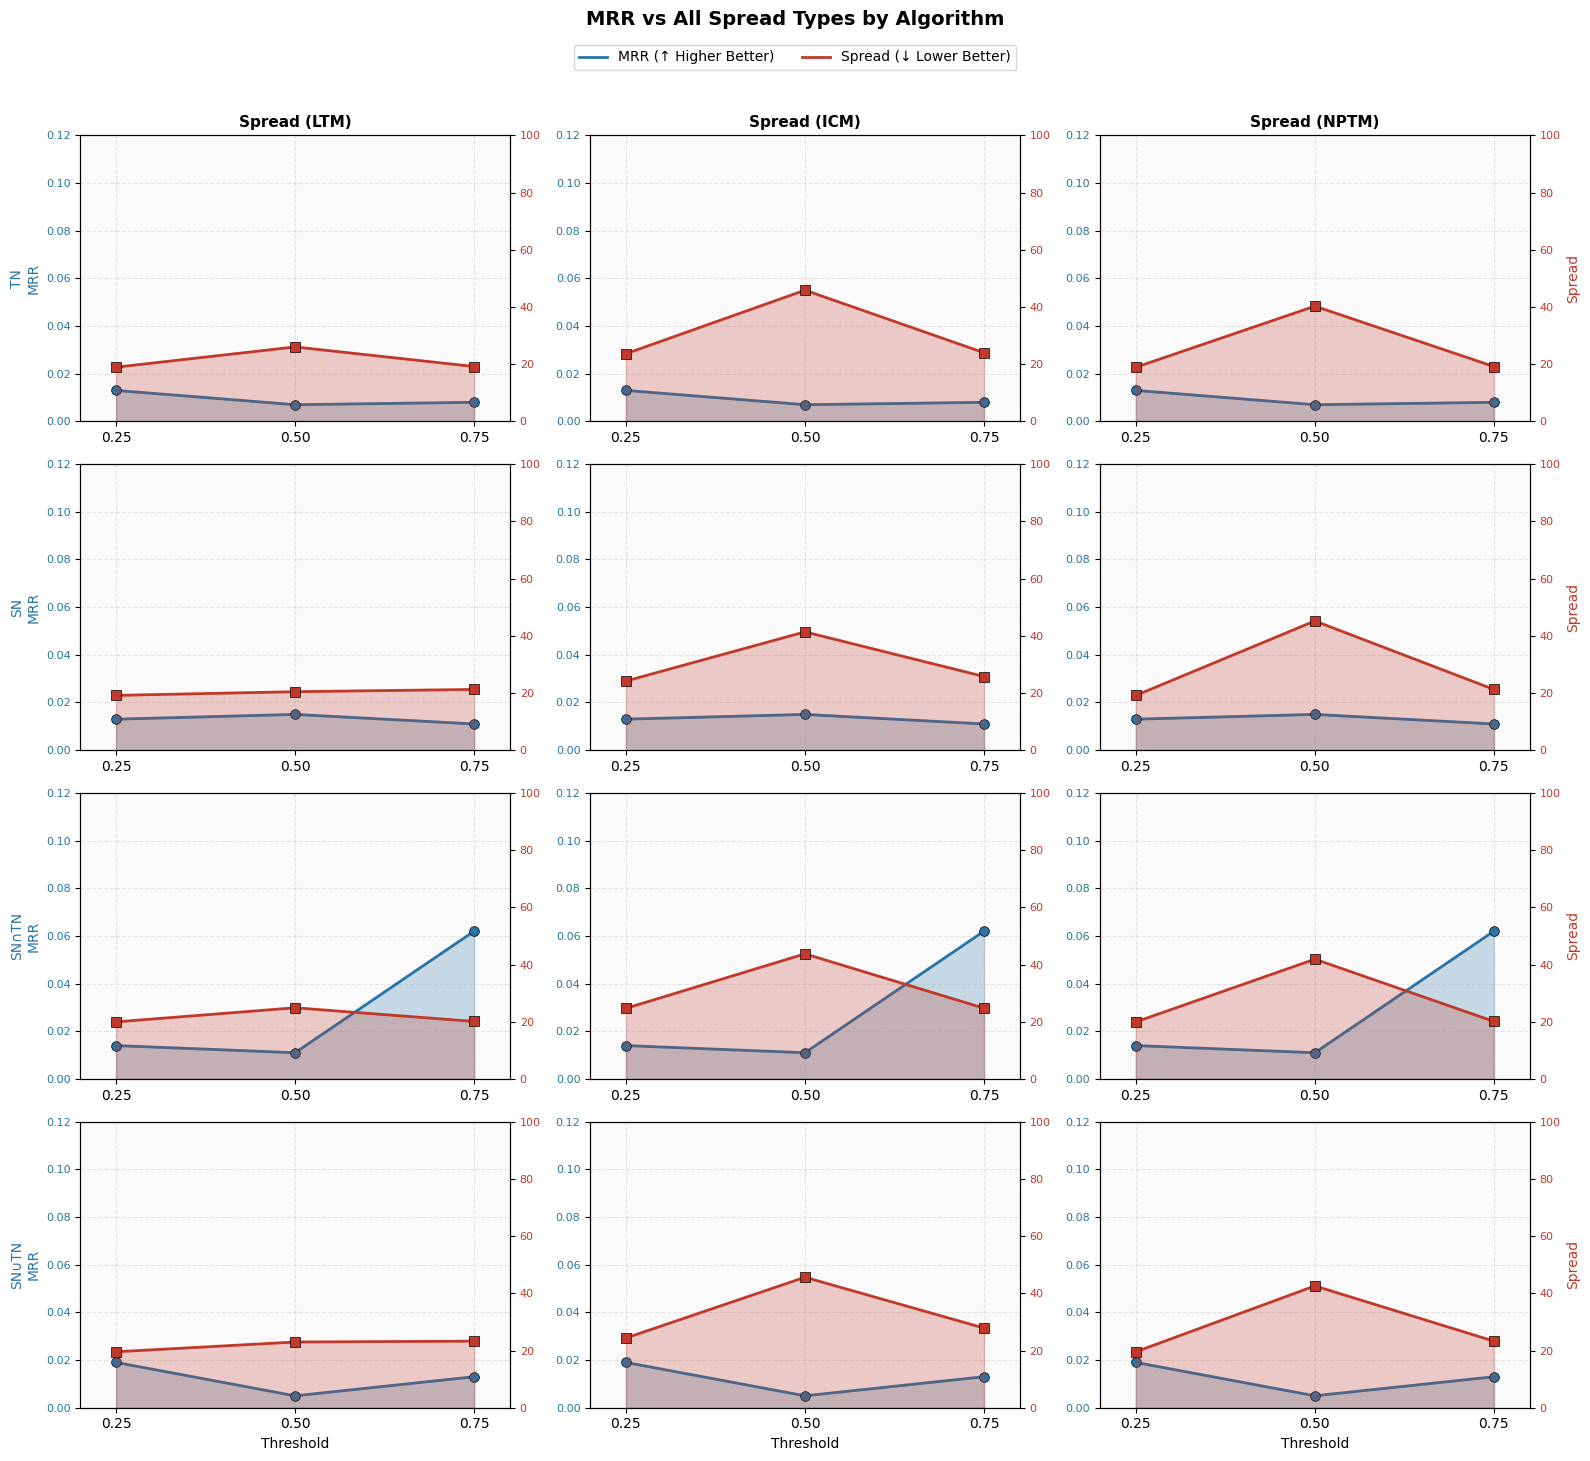

In [2]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = ['MA-GraphRec(TN)', 'MA-GraphRec(SN)', 'MA-GraphRec(SN∩TN)', 'MA-GraphRec(SN∪TN)']
thresholds = [0.25, 0.50, 0.75]
x_smooth = np.linspace(0.25, 0.75, 100)

mrr_data = {
    'MA-GraphRec(TN)': [0.013, 0.007, 0.008],
    'MA-GraphRec(SN)': [0.013, 0.015, 0.011],
    'MA-GraphRec(SN∩TN)': [0.014, 0.011, 0.062],
    'MA-GraphRec(SN∪TN)': [0.019, 0.005, 0.013]
}

all_spread_data = {
    'LTM': {
        'MA-GraphRec(TN)': [18.95, 26.03, 19.18], 
        'MA-GraphRec(SN)': [19.15, 20.44, 21.23],
        'MA-GraphRec(SN∩TN)': [19.95, 24.88, 20.10], 
        'MA-GraphRec(SN∪TN)': [19.56, 22.97, 23.28]
    },
    'ICM': {
        'MA-GraphRec(TN)': [23.66, 45.87, 24.00], 
        'MA-GraphRec(SN)': [24.16, 41.36, 25.75],
        'MA-GraphRec(SN∩TN)': [24.69, 43.74, 24.73], 
        'MA-GraphRec(SN∪TN)': [24.38, 45.61, 27.85]
    },
    'NPTM': {
        'MA-GraphRec(TN)': [18.93, 40.28, 19.17], 
        'MA-GraphRec(SN)': [19.14, 45.17, 21.23],
        'MA-GraphRec(SN∩TN)': [19.94, 41.87, 20.11], 
        'MA-GraphRec(SN∪TN)': [19.56, 42.58, 23.28]
    }
}

spread_types = ['LTM', 'ICM', 'NPTM']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for row_idx, algo in enumerate(algorithms):
    for col_idx, spread_type in enumerate(spread_types):
        ax1 = axes[row_idx, col_idx]
        ax2 = ax1.twinx()
        
        mrr_values = mrr_data[algo]
        spread_values = all_spread_data[spread_type][algo]
        
        mrr_smooth = np.interp(x_smooth, thresholds, mrr_values)
        spread_smooth = np.interp(x_smooth, thresholds, spread_values)
        
        # Plot MRR
        ax1.fill_between(x_smooth, mrr_smooth, alpha=0.25, color='#2874A6')
        ax1.plot(x_smooth, mrr_smooth, color='#2874A6', linewidth=2, label='MRR')
        ax1.plot(thresholds, mrr_values, 'o', color='#2874A6', markersize=7,
                 markeredgecolor='black', markeredgewidth=0.5)
        
        # Plot Spread
        ax2.fill_between(x_smooth, spread_smooth, alpha=0.25, color='#C0392B')
        ax2.plot(x_smooth, spread_smooth, color='#C0392B', linewidth=2, label=f'Spread ({spread_type})')
        ax2.plot(thresholds, spread_values, 's', color='#C0392B', markersize=7,
                 markeredgecolor='black', markeredgewidth=0.5)
        
        ax1.set_ylim(0, 0.12)
        ax2.set_ylim(0, 100)
        ax1.set_xlim(0.2, 0.8)
        ax1.set_xticks(thresholds)
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_facecolor('#fafafa')
        
        # Labels
        if row_idx == 3:
            ax1.set_xlabel('Threshold', fontsize=10)
        if col_idx == 0:
            algo_short = algo.split('(')[1].replace(')', '')
            ax1.set_ylabel(f'{algo_short}\nMRR', color='#2874A6', fontsize=10)
        if col_idx == 2:
            ax2.set_ylabel('Spread', color='#C0392B', fontsize=10)
        
        ax1.tick_params(axis='y', labelcolor='#2874A6', labelsize=8)
        ax2.tick_params(axis='y', labelcolor='#C0392B', labelsize=8)
        
        if row_idx == 0:
            ax1.set_title(f'Spread ({spread_type})', fontsize=11, fontweight='bold')
        
        # Legend only for first subplot
        if row_idx == 0 and col_idx == 0:
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()

# Add single legend at top
fig.legend(lines1 + lines2, ['MRR (↑ Higher Better)', 'Spread (↓ Lower Better)'], 
           loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('MRR vs All Spread Types by Algorithm', fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('mrr_all_spreads_grid.pdf', format='pdf', dpi=600, bbox_inches='tight')
plt.savefig('mrr_all_spreads_grid.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

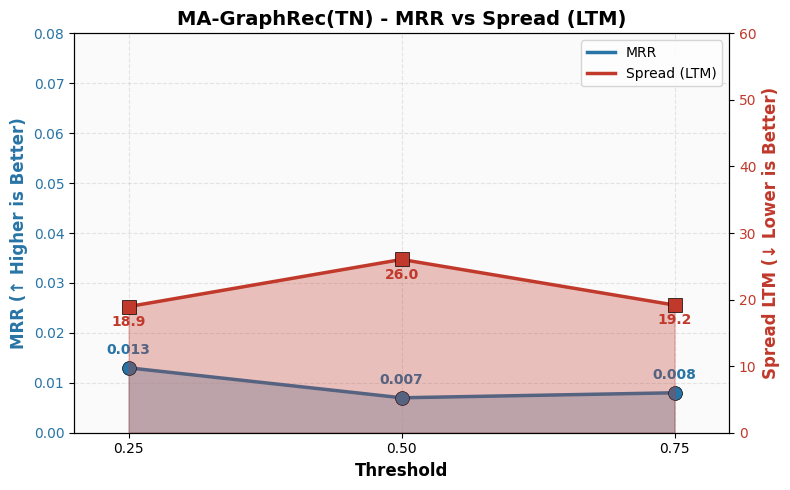

Saved: mrr_spread_LTM_TN.pdf and mrr_spread_LTM_TN.png


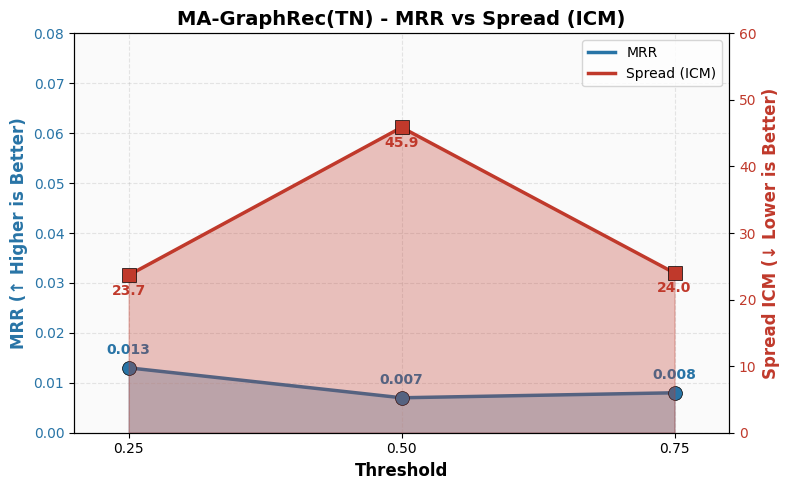

Saved: mrr_spread_ICM_TN.pdf and mrr_spread_ICM_TN.png


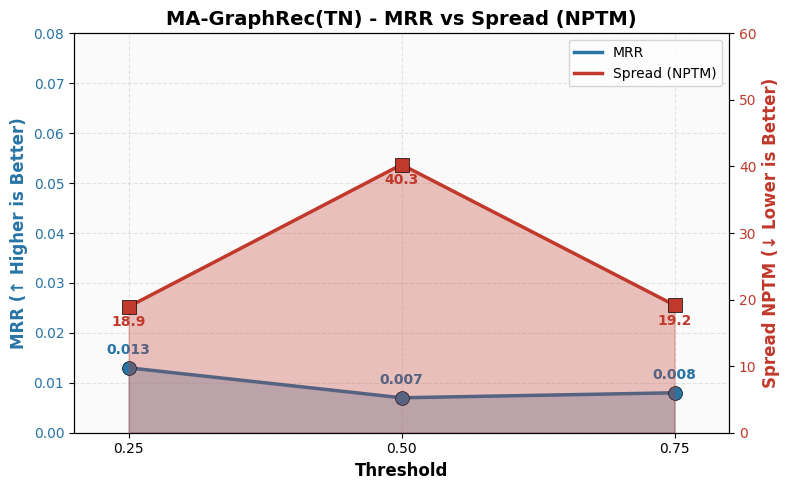

Saved: mrr_spread_NPTM_TN.pdf and mrr_spread_NPTM_TN.png


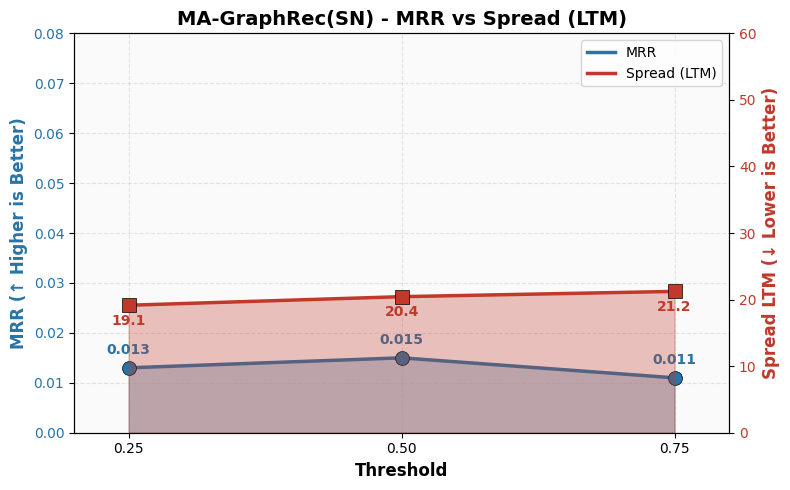

Saved: mrr_spread_LTM_SN.pdf and mrr_spread_LTM_SN.png


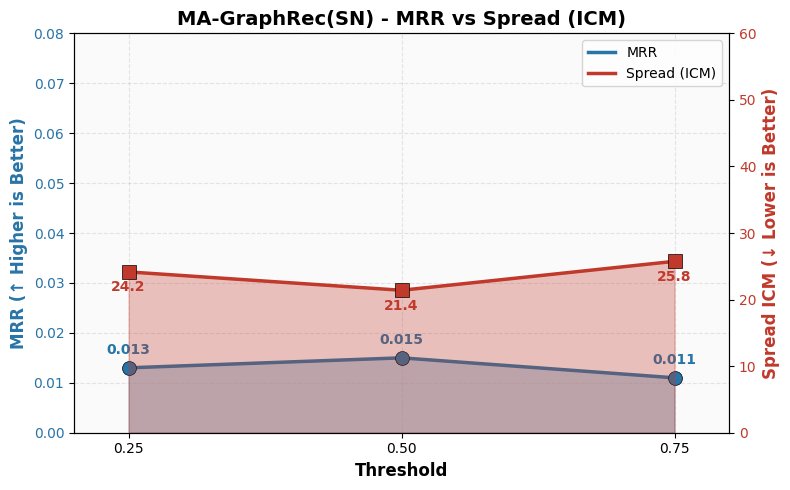

Saved: mrr_spread_ICM_SN.pdf and mrr_spread_ICM_SN.png


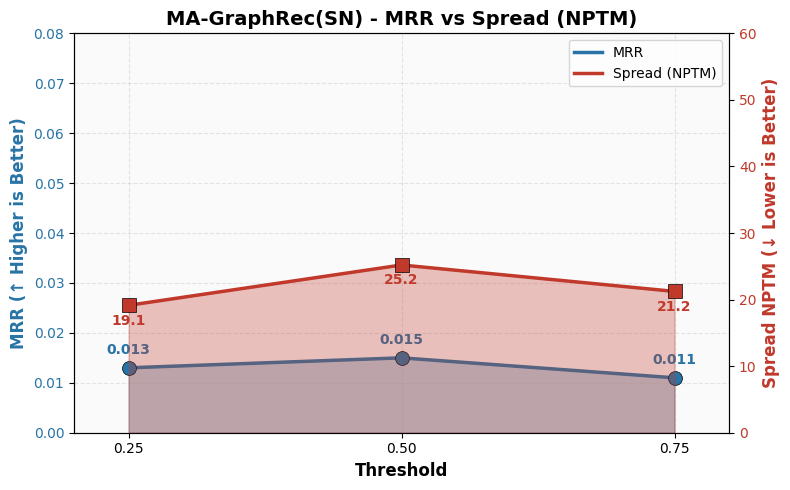

Saved: mrr_spread_NPTM_SN.pdf and mrr_spread_NPTM_SN.png


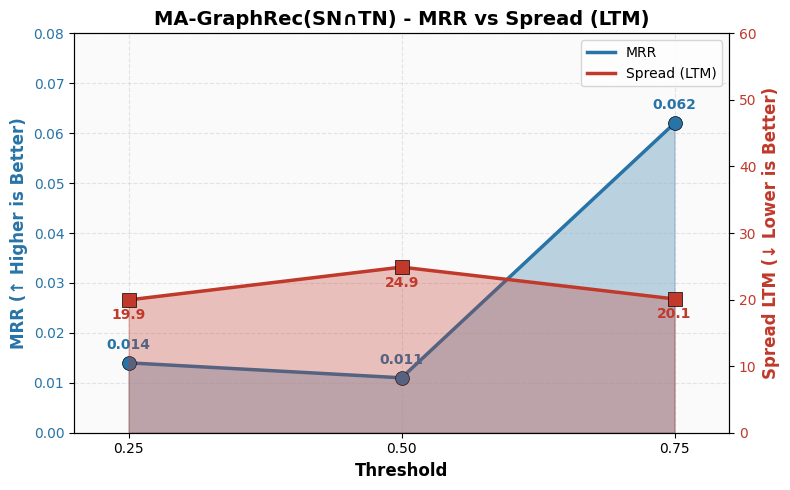

Saved: mrr_spread_LTM_SN_intersection_TN.pdf and mrr_spread_LTM_SN_intersection_TN.png


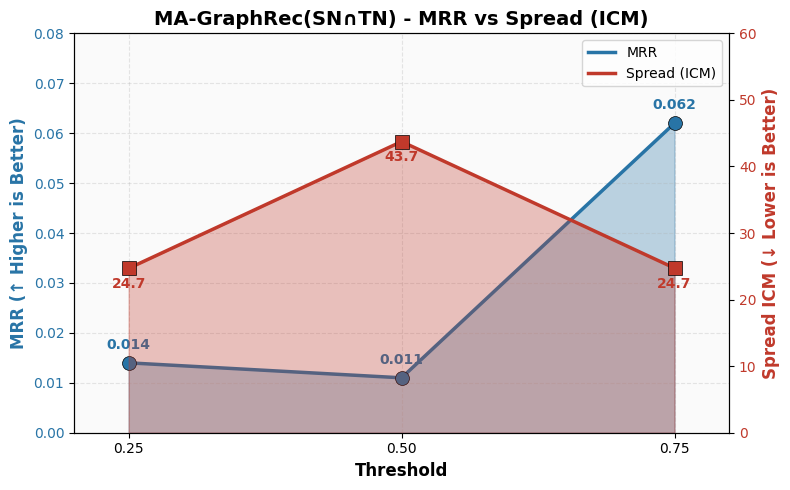

Saved: mrr_spread_ICM_SN_intersection_TN.pdf and mrr_spread_ICM_SN_intersection_TN.png


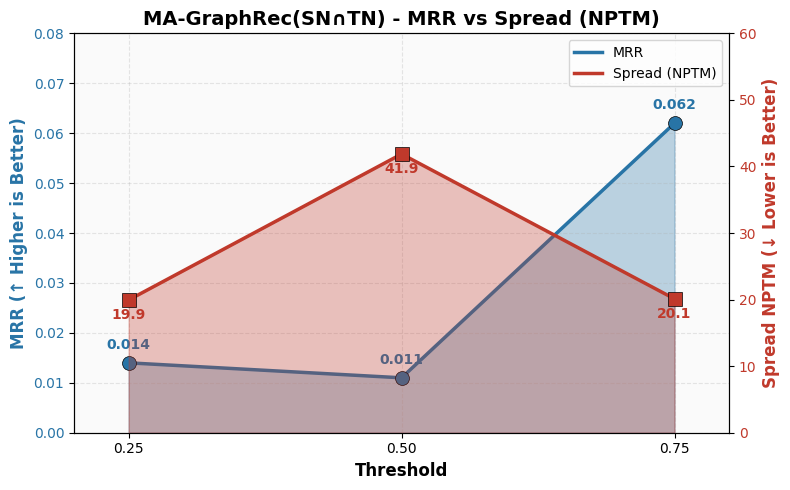

Saved: mrr_spread_NPTM_SN_intersection_TN.pdf and mrr_spread_NPTM_SN_intersection_TN.png


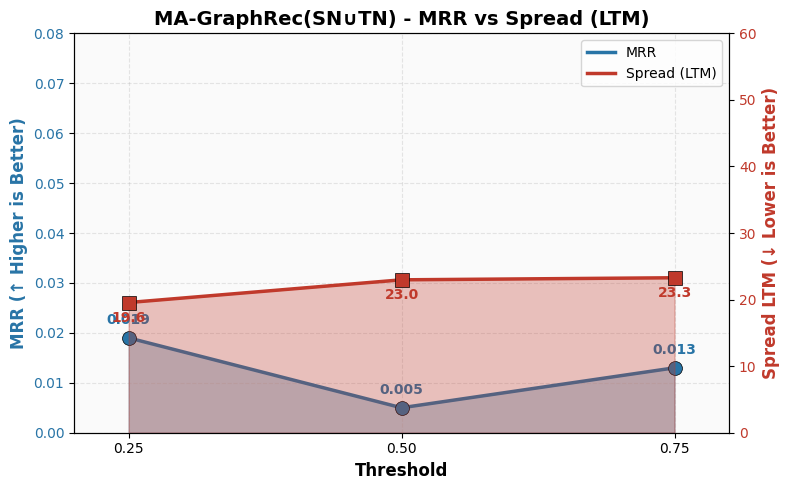

Saved: mrr_spread_LTM_SN_union_TN.pdf and mrr_spread_LTM_SN_union_TN.png


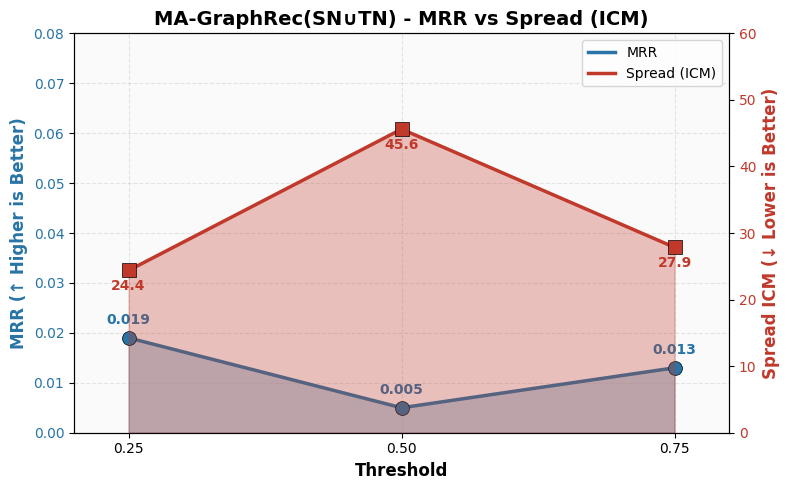

Saved: mrr_spread_ICM_SN_union_TN.pdf and mrr_spread_ICM_SN_union_TN.png


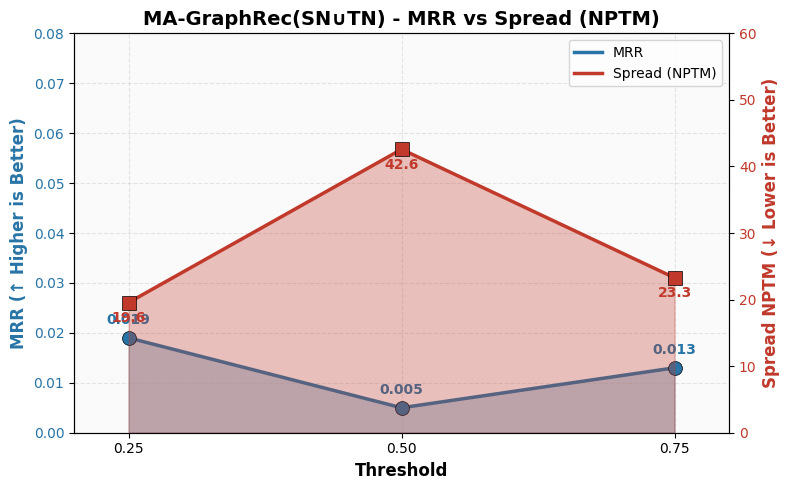

Saved: mrr_spread_NPTM_SN_union_TN.pdf and mrr_spread_NPTM_SN_union_TN.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = ['MA-GraphRec(TN)', 'MA-GraphRec(SN)', 'MA-GraphRec(SN∩TN)', 'MA-GraphRec(SN∪TN)']
thresholds = [0.25, 0.50, 0.75]
x_smooth = np.linspace(0.25, 0.75, 100)

mrr_data = {
    'MA-GraphRec(TN)': [0.013, 0.007, 0.008],
    'MA-GraphRec(SN)': [0.013, 0.015, 0.011],
    'MA-GraphRec(SN∩TN)': [0.014, 0.011, 0.062],
    'MA-GraphRec(SN∪TN)': [0.019, 0.005, 0.013]
}

all_spread_data = {
    'LTM': {
        'MA-GraphRec(TN)': [18.95, 26.03, 19.18], 
        'MA-GraphRec(SN)': [19.15, 20.44, 21.23],
        'MA-GraphRec(SN∩TN)': [19.95, 24.88, 20.10], 
        'MA-GraphRec(SN∪TN)': [19.56, 22.97, 23.28]
    },
    'ICM': {
        'MA-GraphRec(TN)': [23.66, 45.87, 24.00], 
        'MA-GraphRec(SN)': [24.16, 21.4, 25.75],
        'MA-GraphRec(SN∩TN)': [24.69, 43.74, 24.73], 
        'MA-GraphRec(SN∪TN)': [24.38, 45.61, 27.85]
    },
    'NPTM': {
        'MA-GraphRec(TN)': [18.93, 40.28, 19.17], 
        'MA-GraphRec(SN)': [19.14, 25.2, 21.23],
        'MA-GraphRec(SN∩TN)': [19.94, 41.87, 20.11], 
        'MA-GraphRec(SN∪TN)': [19.56, 42.58, 23.28]
    }
}

spread_types = ['LTM', 'ICM', 'NPTM']

# Generate individual plot for each algorithm and each spread type
for algo in algorithms:
    for spread_type in spread_types:
        fig, ax1 = plt.subplots(figsize=(8, 5))
        ax2 = ax1.twinx()
        
        # Get data
        mrr_values = mrr_data[algo]
        spread_values = all_spread_data[spread_type][algo]
        
        # Interpolate for smooth curves
        mrr_smooth = np.interp(x_smooth, thresholds, mrr_values)
        spread_smooth = np.interp(x_smooth, thresholds, spread_values)
        
        # Plot MRR with area
        ax1.fill_between(x_smooth, mrr_smooth, alpha=0.3, color='#2874A6')
        ax1.plot(x_smooth, mrr_smooth, color='#2874A6', linewidth=2.5, label='MRR')
        ax1.plot(thresholds, mrr_values, 'o', color='#2874A6', markersize=10,
                 markeredgecolor='black', markeredgewidth=0.5)
        # Add value annotations for MRR
        for x, y in zip(thresholds, mrr_values):
            ax1.annotate(f'{y:.3f}', (x, y), textcoords="offset points", 
                        xytext=(0, 10), ha='center', fontsize=10, color='#2874A6', fontweight='bold')
        
        ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
        ax1.set_ylabel('MRR (↑ Higher is Better)', color='#2874A6', fontsize=12, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor='#2874A6')
        ax1.set_ylim(0, 0.08)
        ax1.set_xlim(0.2, 0.8)
        ax1.set_xticks(thresholds)
        
        # Plot Spread with area
        ax2.fill_between(x_smooth, spread_smooth, alpha=0.3, color='#C0392B')
        ax2.plot(x_smooth, spread_smooth, color='#C0392B', linewidth=2.5, label=f'Spread ({spread_type})')
        ax2.plot(thresholds, spread_values, 's', color='#C0392B', markersize=10,
                 markeredgecolor='black', markeredgewidth=0.5)
        # Add value annotations for Spread
        for x, y in zip(thresholds, spread_values):
            ax2.annotate(f'{y:.1f}', (x, y), textcoords="offset points", 
                        xytext=(0, -14), ha='center', fontsize=10, color='#C0392B', fontweight='bold')
        
        ax2.set_ylabel(f'Spread {spread_type} (↓ Lower is Better)', color='#C0392B', fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor='#C0392B')
        ax2.set_ylim(0, 60)
        
        # Title and legend
        algo_short = algo.split('(')[1].replace(')', '')
        ax1.set_title(f'MA-GraphRec({algo_short}) - MRR vs Spread ({spread_type})', fontsize=14, fontweight='bold')
        
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)
        
        ax1.grid(True, alpha=0.3, linestyle='--')
        ax1.set_facecolor('#fafafa')
        
        plt.tight_layout()
        
        # Save individual files
        algo_filename = algo_short.replace("∩", "_intersection_").replace("∪", "_union_")
        filename = f'mrr_spread_{spread_type}_{algo_filename}'
        plt.savefig(f'{filename}.pdf', format='pdf', dpi=600, bbox_inches='tight')
        plt.savefig(f'{filename}.png', format='png', dpi=600, bbox_inches='tight')
        plt.show()
        
        print(f"Saved: {filename}.pdf and {filename}.png")